### Imports

In [1]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
from pathlib import Path
from tqdm import trange
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

### Reproducibility setup

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Paths

In [3]:
# base_dir = Path("C:/Users/mills/Desktop/Angione Lab/OC")
# adata_gene_path = base_dir / "spatial" / "OC_adata_hvg_graph_gene.h5ad"
# adata_cnn_path = base_dir / "spatial" / "OC_adata_hvg_with_cnn.h5ad"
# output_path = base_dir / "spatial" / "OC_adata_hvg_multimodal_graph.h5ad"

# output_path.parent.mkdir(exist_ok=True)

In [4]:
base_dir = Path("C:/Users/mills/Desktop/Angione Lab/OC")

# INPUTS (from spatial_2)
adata_gene_path = base_dir / "spatial_2" / "OC_adata_hvg_graph_gene.h5ad"
adata_cnn_path  = base_dir / "spatial_2" / "OC_adata_hvg_with_cnn.h5ad"

# OUTPUT (also to spatial_2)
output_path = base_dir / "spatial_2" / "OC_adata_hvg_multimodal_graph.h5ad"

# ensure directory exists
output_path.parent.mkdir(exist_ok=True)

### Load AnnData with gene embeddings and CNN embeddings

In [5]:
adata_gene = sc.read_h5ad(adata_gene_path)
adata_cnn = sc.read_h5ad(adata_cnn_path)

# Ensure same cell order
assert (adata_gene.obs_names == adata_cnn.obs_names).all(), "Cell ordering mismatch!"

# Merge CNN embeddings into gene AnnData
adata = adata_gene.copy()
adata.obsm['X_cnn'] = adata_cnn.obsm['X_cnn']

### Extract features

In [6]:
X_gene = adata.obsm["X_graph_gene"]
if not isinstance(X_gene, np.ndarray):
    X_gene = X_gene.toarray()  # only needed if sparse

X_cnn = adata.obsm["X_cnn"]

print("Gene features shape:", X_gene.shape)
print("CNN features shape:", X_cnn.shape)

Gene features shape: (63072, 150)
CNN features shape: (63072, 512)


### Scale CNN embeddings

In [7]:
scaler = StandardScaler()
X_cnn_scaled = scaler.fit_transform(X_cnn)

### Combine multimodal features

In [8]:
X_multi = np.concatenate([X_gene, X_cnn_scaled], axis=1)
print("Combined multimodal feature matrix shape:", X_multi.shape)

# Optional: normalize combined features
X_multi = StandardScaler().fit_transform(X_multi)

Combined multimodal feature matrix shape: (63072, 662)


### Spatial coordinates

In [9]:
coords = adata.obs[["center_x","center_y"]].values.astype(float)

scaler = MinMaxScaler()
coords = scaler.fit_transform(coords)

print("Spatial coordinates shape:", coords.shape)

Spatial coordinates shape: (63072, 2)


In [10]:
# coords = adata.obs[["center_x","center_y"]].values
# print("Spatial coordinates shape:", coords.shape)

### Build k-NN spatial graph

In [11]:
k = 10
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

edges = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append([i, j])

# IMPORTANT: PyG requires long dtype
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
print("Edge index shape:", edge_index.shape)

Edge index shape: torch.Size([2, 567648])


### Convert to PyTorch Geometric Data

In [12]:
x = torch.tensor(X_multi, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[63072, 662], edge_index=[2, 567648])


### Multimodal Graph Transformer Network

In [13]:
class GraphTransformer(nn.Module):
    def __init__(self, in_channels, hidden=128):
        super().__init__()
        self.conv1 = TransformerConv(in_channels, hidden, heads=2)
        self.conv2 = TransformerConv(hidden*2, hidden, heads=2)
        self.lin = nn.Linear(hidden*2, hidden)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x

### Initialize model and optimizer

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphTransformer(in_channels=data.x.shape[1]).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train Graph Transformer Network

In [15]:
epochs = 200
loss_history = []

pbar = trange(epochs, desc="Training Multimodal GNN", unit="epoch")
for epoch in pbar:
    optimizer.zero_grad()
    embeddings = model(data.x, data.edge_index)
    # Autoencoder loss: reconstruct original combined features
    loss = F.mse_loss(embeddings, data.x[:, :embeddings.shape[1]])
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    # Logging in tqdm
    pbar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

Epoch 200 | Loss: 0.0649: 100%|██████████| 200/200 [17:06<00:00,  5.13s/epoch]


### Plot training loss

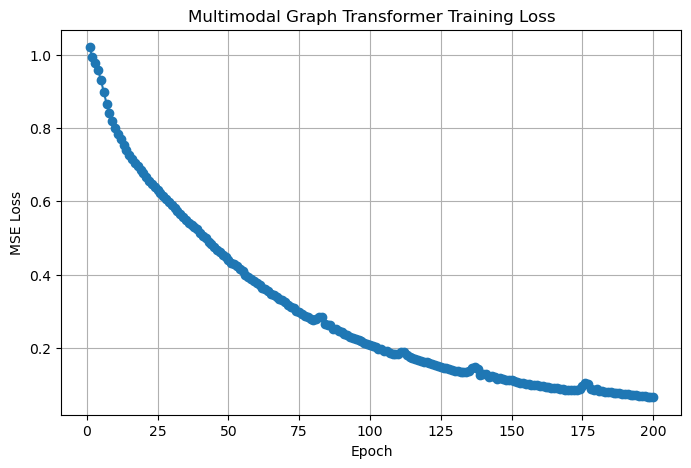

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_history, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multimodal Graph Transformer Training Loss")
plt.grid(True)
plt.show()

### Save Multimodal Graph Embeddings

In [17]:
model.eval()
with torch.no_grad():
    graph_embeddings = model(data.x, data.edge_index).cpu().numpy()

adata.obsm["X_graph_multimodal"] = graph_embeddings
adata.write(output_path)
print("Multimodal graph embeddings saved to:", output_path)

Multimodal graph embeddings saved to: C:\Users\mills\Desktop\Angione Lab\OC\spatial_2\OC_adata_hvg_multimodal_graph.h5ad
